# Lista 6

## Imports

In [337]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import re
import ipywidgets as widgets
from scipy.cluster.hierarchy import dendrogram, linkage
import time
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import calinski_harabasz_score

## Zadanie 1

In [56]:
xs1 = np.random.normal(0, 0.1, 100)
ys1 = np.random.normal(0, 50, 100)

data1 = np.column_stack((xs1, ys1, np.zeros(100)))

xs2 = np.random.normal(5, 0.1, 100)
ys2 = np.random.normal(5, 50, 100)

data2 = np.column_stack((xs2, ys2, np.ones(100)))

data = np.vstack((data1, data2))

In [57]:
data_df = pd.DataFrame(data, columns=['x', 'y', 'color'])

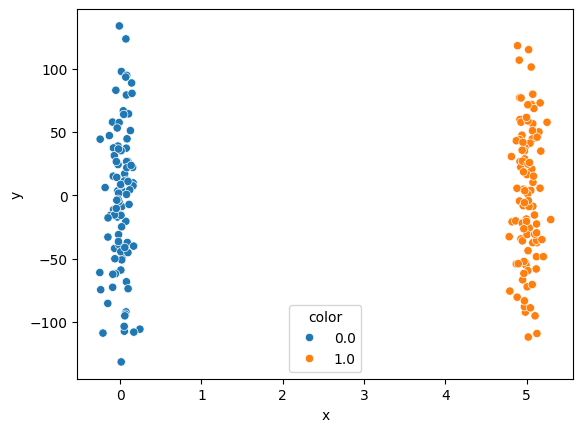

In [58]:
sns.scatterplot(x='x', y='y', data=data_df, hue='color')
plt.show()

In [59]:
X = data_df.drop('color', axis=1)
y = data_df['color']

<Axes: xlabel='x', ylabel='y'>

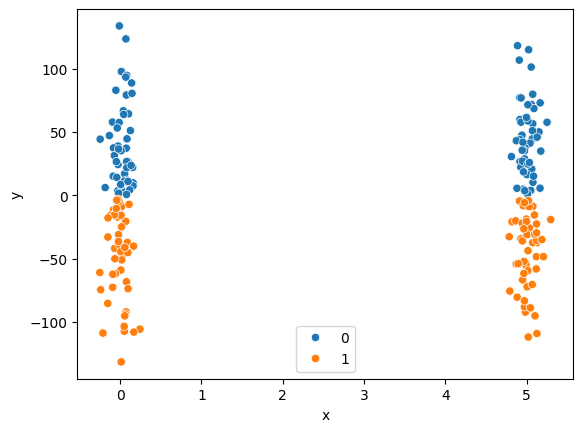

In [77]:
res = KMeans(2).fit_predict(X)
sns.scatterplot(x='x', y='y', data=data_df, hue=res)
plt.show()

<Axes: xlabel='x', ylabel='y'>

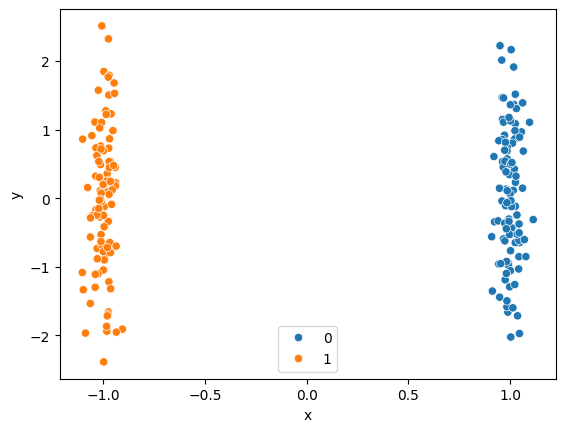

In [75]:
X_scaled = StandardScaler().fit_transform(X)
data_df_scaled = pd.DataFrame(X_scaled, columns=['x', 'y'])
res = KMeans(2).fit_predict(X_scaled)
sns.scatterplot(x='x', y='y', data=data_df_scaled, hue=res)
plt.show()

Wczesniej nie dzialalo, dlatego, ze bardzo duze odchylenie standardowe cechy y powoduje, ze postawienie srodka pomiedzy dwoma grupami danych zminimalizuje odleglosci bardziej niz srodek w grupie danych.

Po zstandaryzowaniu danych obie osie x i y maja takie same odchylenie standardowe, wiec kmeans radzi sobie lepiej.

## Zadanie 2

PNG ma RGBA, a nas interesuje tylko B

Poniewaz w obrazach os y leci w dol, a na wykresach idzie do gory, mam odwrocone dane. Nie wplywa to na obliczenia

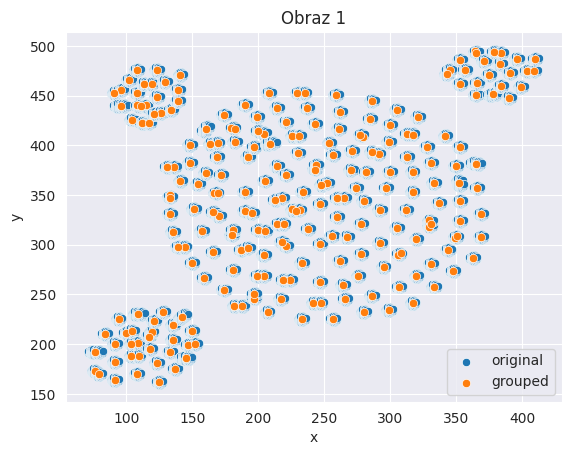

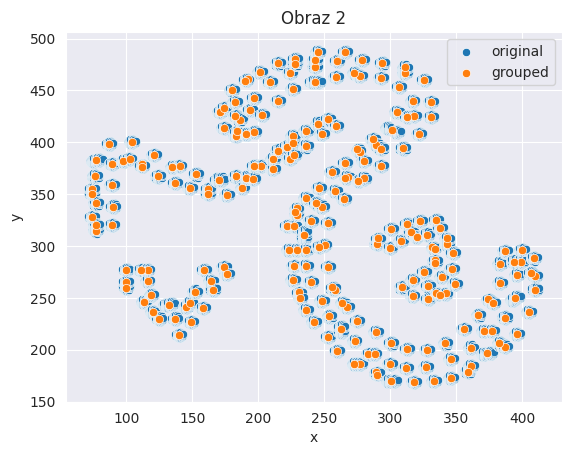

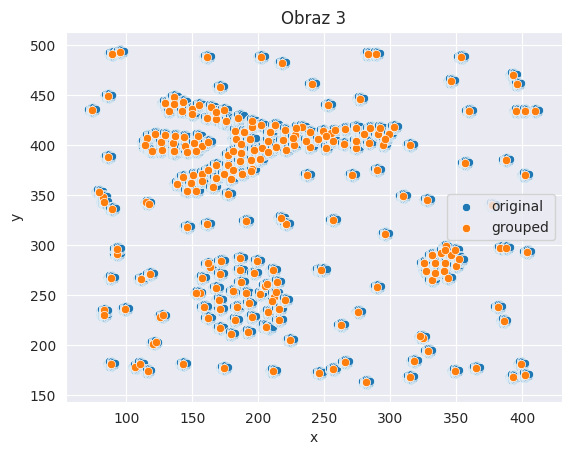

In [80]:
images = []
for i in range(1, 4)  :
    img = Image.open(f'figure_{i}_without_frame.png')
    blue = np.transpose(np.where(np.array(img)[:, :, 2] != 255))
    blue_df = pd.DataFrame(blue, columns=['x', 'y'])
    sns.scatterplot(x='x', y='y', data=blue_df, label='original')

    model = KMeans(250)
    grouped = model.fit_predict(blue)
    center_df = pd.DataFrame(model.cluster_centers_, columns=['x', 'y'])
    sns.scatterplot(x='x', y='y', data=center_df, label='grouped')
    plt.title(f"Obraz {i}")
    plt.legend()
    plt.show()

    images.append(center_df)

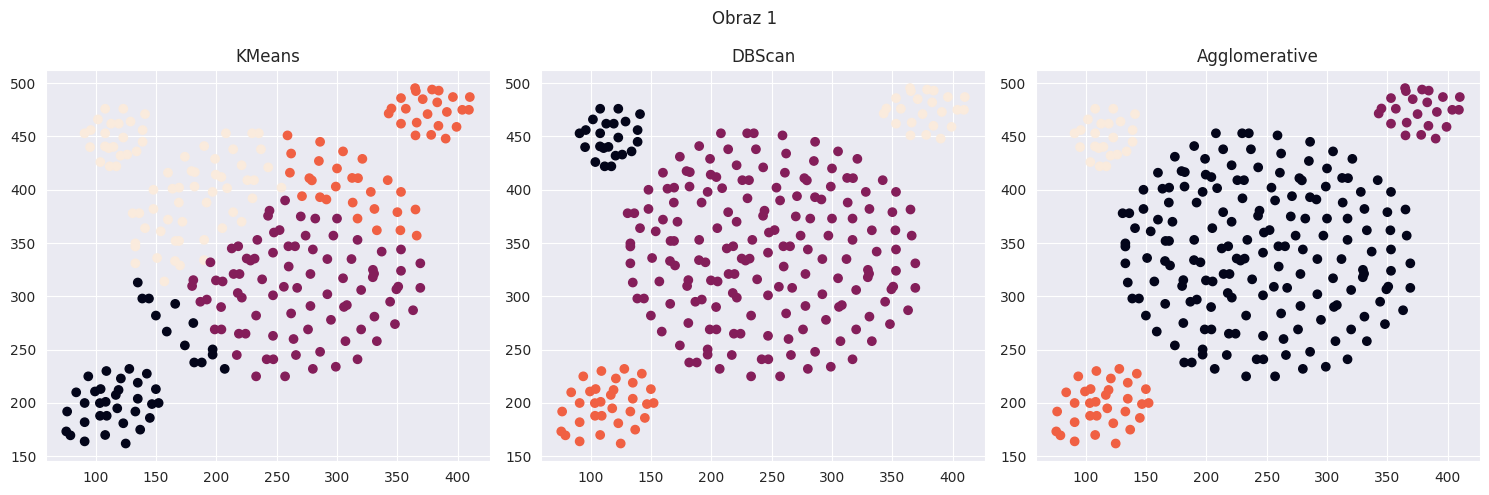

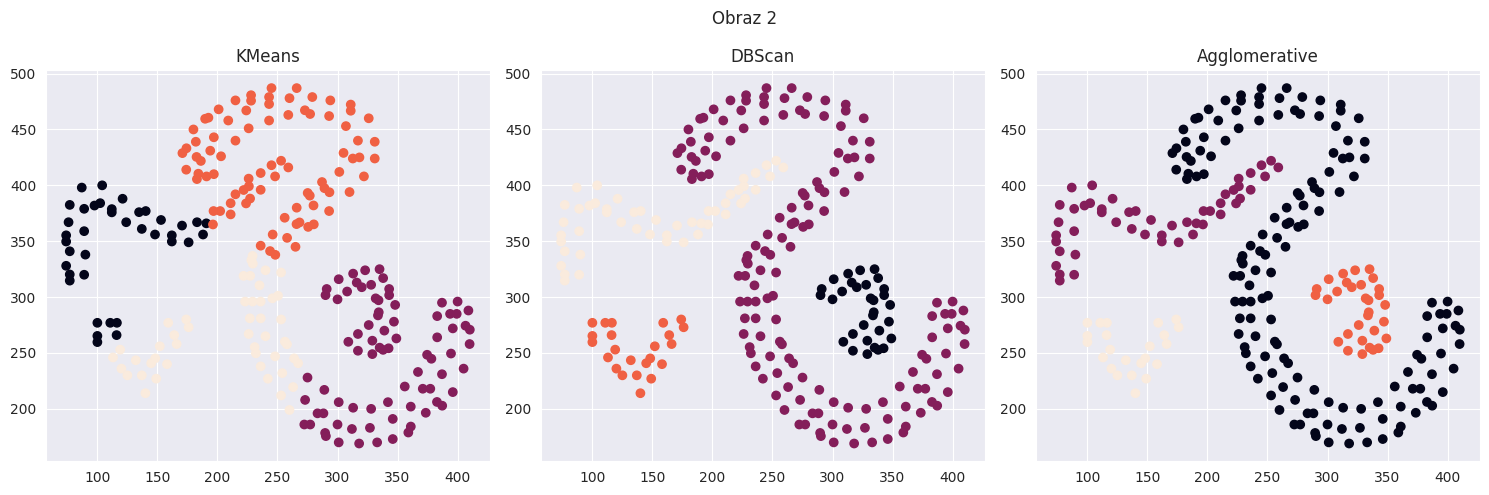

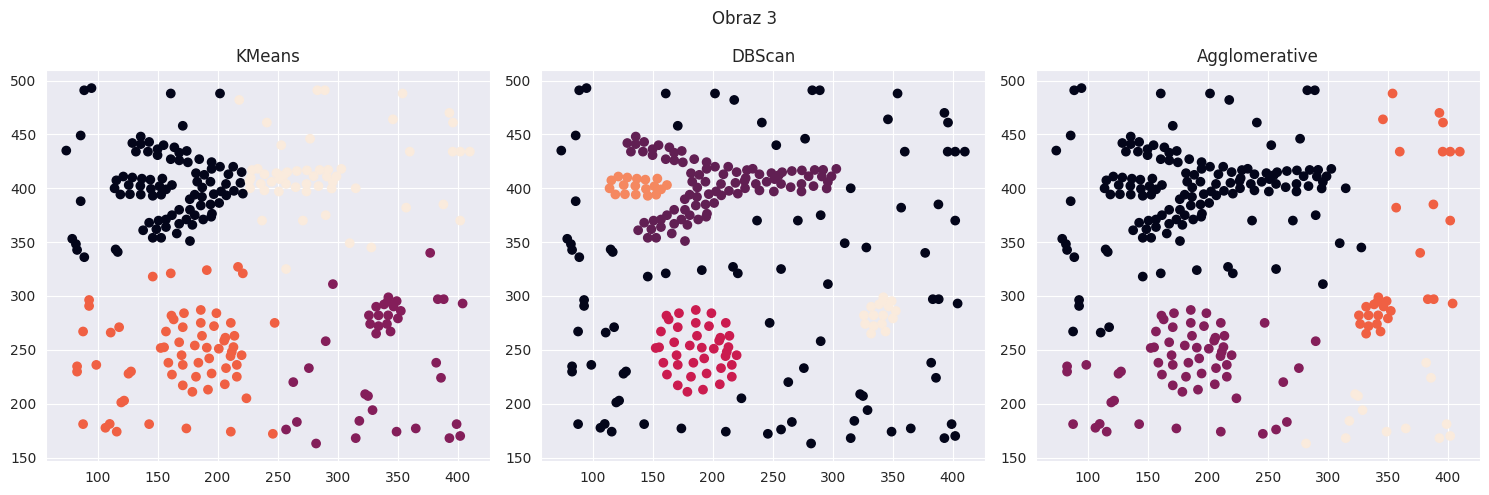

In [159]:
params_dbscan = [[20, 1], [20, 1], [19, 7]]
params_agg = ['single', 'single', 'complete']

for i in range(3):
    data = images[i]
    kmeans = KMeans(4).fit_predict(data)
    eps, min_samples = params_dbscan[i]
    dbscan = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(data)
    agg = AgglomerativeClustering(4, linkage=params_agg[i]).fit_predict(data)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].scatter(data['x'], data['y'], c=kmeans)
    axes[0].set_title('KMeans')
    axes[1].scatter(data['x'], data['y'], c=dbscan)
    axes[1].set_title('DBScan')
    axes[2].scatter(data['x'], data['y'], c=agg)
    axes[2].set_title('Agglomerative')

    fig.suptitle(f"Obraz {i + 1}")
    plt.tight_layout()
    plt.show()

Kmeans nie radzi sobie w zadnym z zadan. W pierwszym obrazie, bo okregi roznia sie wielkoscia. W drugim i trzecim przez nieregularne ksztalty.

DBScan radzi sobie we wszystkich zadaniach. Przy odpowiednio dobranych parametrach kazdy z obrazow zostaje poprawnie pogrupowany. Warto zwrocic uwage, ze osobno grupuje szum w obrazie 3.

Grupowanie hierarchiczne radzi sobie w 1 i 2. W 3 szum oraz fakt, ze grupa obok grupy Y jest zbyt blisko, powoduje, ze nie daje sobie rady.

## Zadanie 3

In [248]:
def compress_image(num_colors):
    all_images = [f for f in os.listdir('.') if re.match(r'^\d+\.', f)]
    for file in all_images:
        img = np.array(Image.open(file))[:, :, :3]

        original_shape = img.shape
        flattened = img.flatten().reshape(-1, 3)
        model = KMeans(num_colors)
        grouped = model.fit_predict(flattened)
        compressed = model.cluster_centers_[grouped].round().astype(np.uint8).reshape(original_shape)

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img)
        axes[0].axis('off')
        axes[0].set_title('Oryginal')
        axes[1].imshow(compressed)
        axes[1].axis('off')
        axes[1].set_title('Skompresowany')
        plt.show()

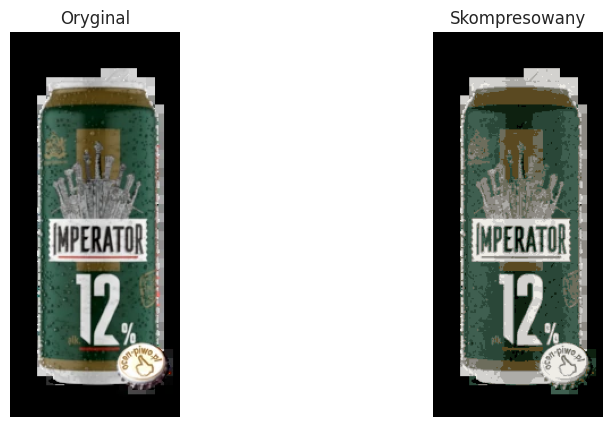

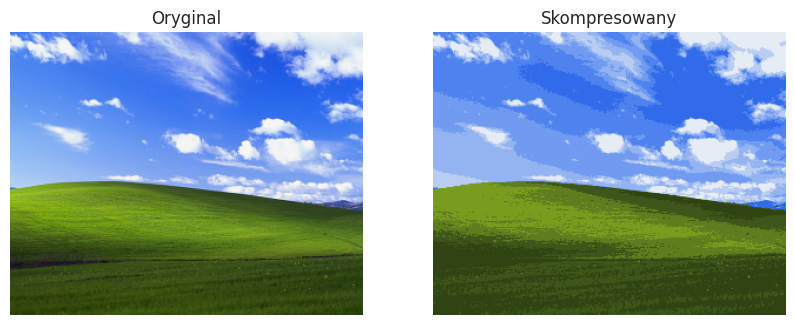

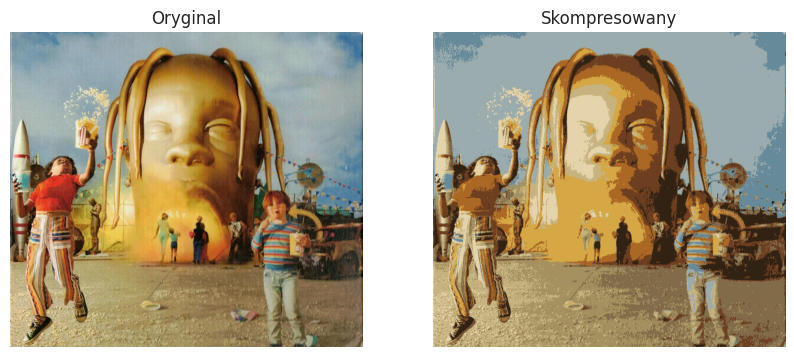

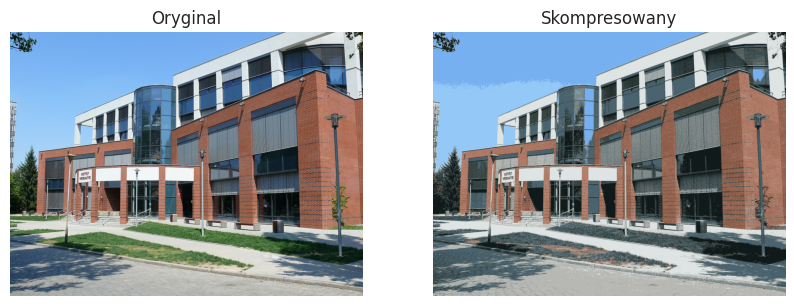

In [252]:
compress_image(10)

In [254]:
widgets.interact(compress_image, num_colors=widgets.IntSlider(
    value=10,
    min=2,
    max=20,
    step=1,
    description='Kolory:',
    continuous_update=False
))

interactive(children=(IntSlider(value=10, continuous_update=False, description='Kolory:', max=20, min=2), Outp…

<function __main__.compress_image(num_colors)>

## Zadanie 4

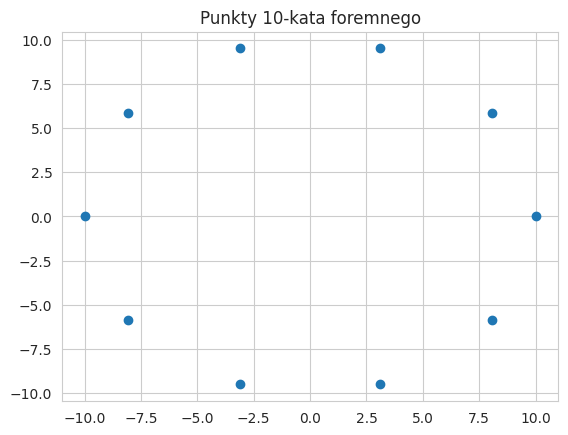

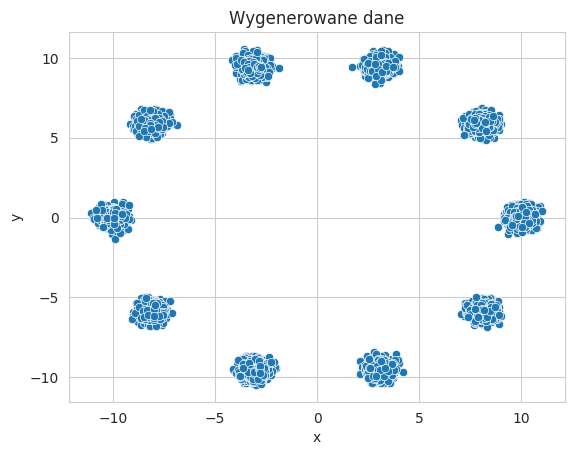

In [342]:
K = 10
M = 1000
sigma = 0.1
radius = 10

x = []
y = []
for i in range(K):
    x.append(radius * np.cos(2 * np.pi * i / K))
    y.append(radius * np.sin(2 * np.pi * i / K))

plt.scatter(x=x, y=y)
plt.title(f'Punkty {K}-kata foremnego')
plt.show()

points = np.vstack((x, y)).T
data = np.vstack([np.random.multivariate_normal(mean=points[i], cov=np.diag((sigma, sigma)), size=M) for i in range(K)])

data_df = pd.DataFrame(data, columns=['x', 'y'])
sns.scatterplot(data=data_df, x='x', y='y')
plt.title('Wygenerowane dane')
plt.show()

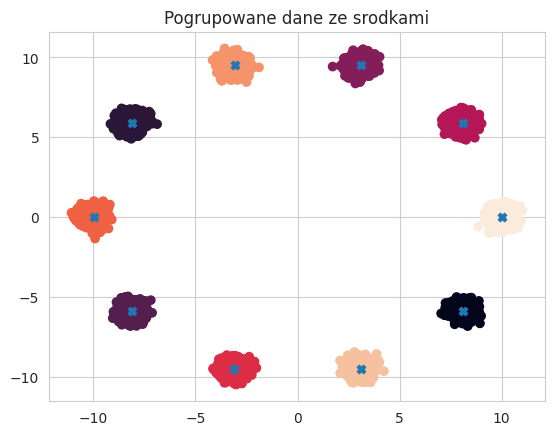

In [343]:
kmeans = KMeans(K)
labels = kmeans.fit_predict(data)

centers = kmeans.cluster_centers_
plt.scatter(x=data[:, 0], y=data[:, 1], c=labels)
plt.scatter(x=centers[:, 0], y=centers[:, 1], marker='X')
plt.title("Pogrupowane dane ze srodkami")
plt.show()

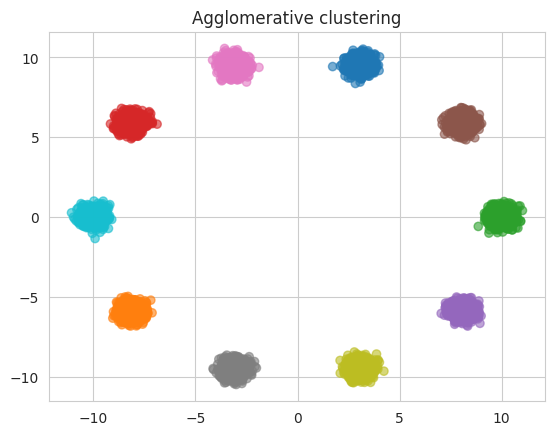

In [344]:
agg = AgglomerativeClustering(n_clusters=K, linkage='ward')
agg_labels = agg.fit_predict(data)
plt.scatter(data[:, 0], data[:, 1], c=agg_labels, cmap='tab10', alpha=0.6)
plt.title('Agglomerative clustering')
plt.show()

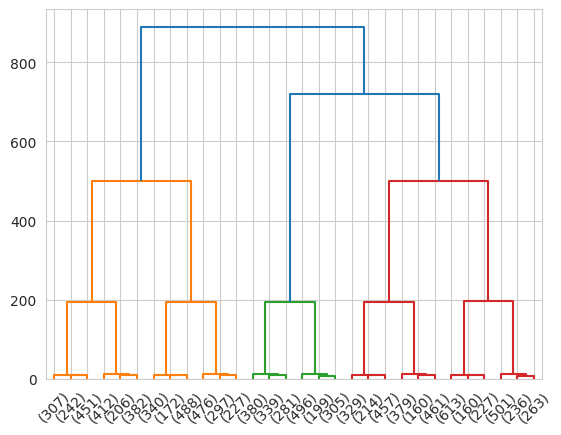

In [345]:
linkage_matrix = linkage(data, method='ward')
dendrogram(linkage_matrix, truncate_mode='lastp', p=30)
plt.show()

Liczby na dole oznaczaja ile punktow sie znajduje w danej galezi

Im wyzej poziome belki (laczenia) tym bardziej oddalone od siebie grupy. Widzimy, ze najwiecej jest na samym dole, co mowi nam o tym, ze grupy sa jawnie podzielone

Kolory oznaczaja optymalne grupy wybrane przez scipy

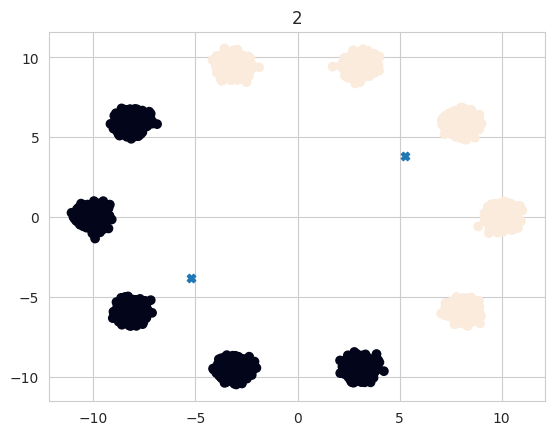

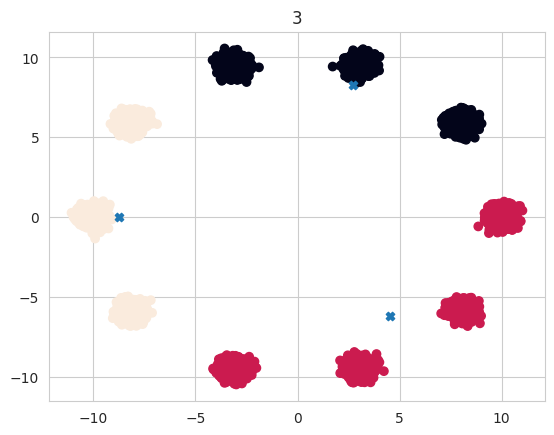

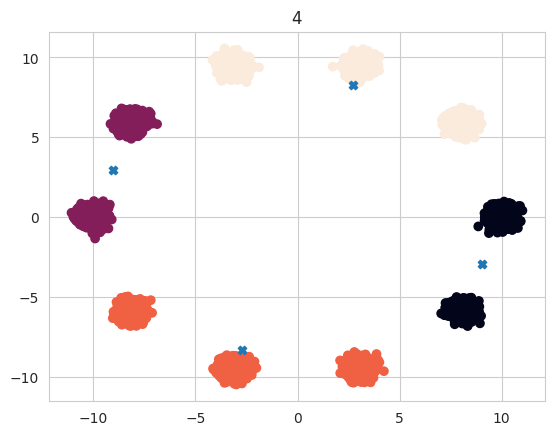

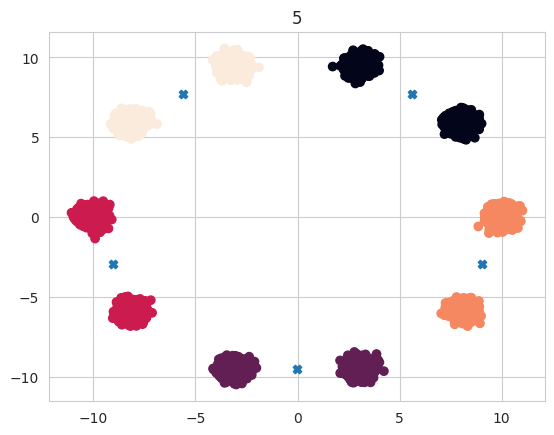

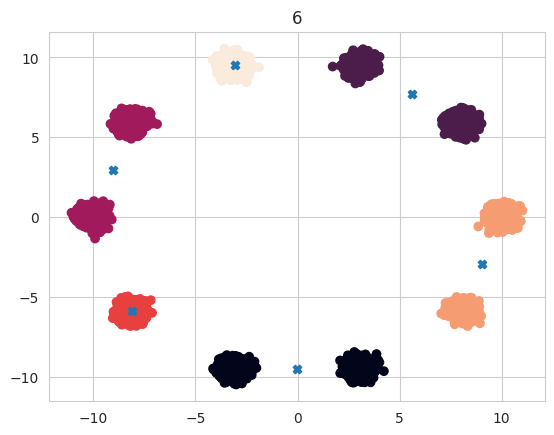

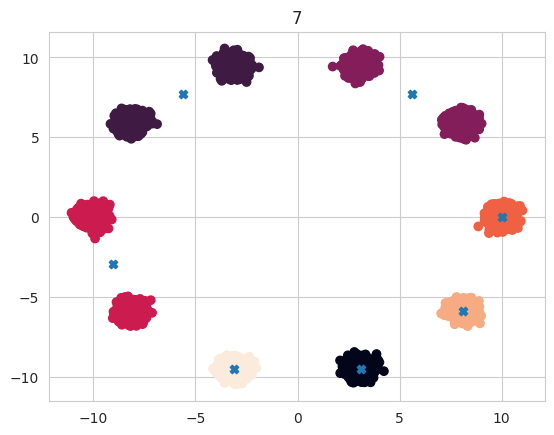

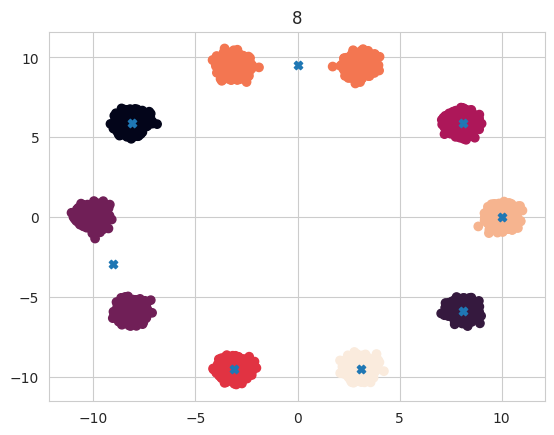

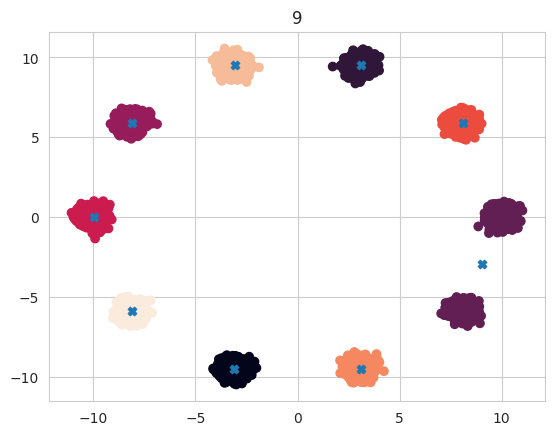

In [348]:
for i in range(2, K):
    kmeans = KMeans(i)
    labels = kmeans.fit_predict(data)

    centers = kmeans.cluster_centers_
    plt.scatter(x=data[:, 0], y=data[:, 1], c=labels)
    plt.scatter(x=centers[:, 0], y=centers[:, 1], marker='X')
    plt.title(i)
    plt.show()

In [340]:
K = 100
M = 10000
sigma = 1
radius = 100

x = []
y = []
for i in range(K):
    x.append(radius * np.cos(2 * np.pi * i / K))
    y.append(radius * np.sin(2 * np.pi * i / K))

points = np.vstack((x, y)).T
data = np.vstack([np.random.multivariate_normal(mean=points[i], cov=np.diag((sigma, sigma)), size=M) for i in range(K)])

start = time.time()
kmeans = KMeans(K, n_init=10)
labels = kmeans.fit_predict(data)
kmeans_time = time.time() - start

start = time.time()
mb_kmeans = MiniBatchKMeans(K, n_init=10, batch_size=1000)
mb_labels = mb_kmeans.fit_predict(data)
mb_kmeans_time = time.time() - start


print(f'Kmeans time: {round(kmeans_time, 3)}s')
print(f'Kmeans score: {calinski_harabasz_score(data, labels)}')
print(f'Minibatch kmeans time: {round(mb_kmeans_time, 3)}s')
print(f'Minibatch kmeans score: {calinski_harabasz_score(data, mb_labels)}')

Kmeans time: 17.958s
Kmeans score: 46330625.19502
Minibatch kmeans time: 0.321s
Minibatch kmeans score: 46326811.651319966


calinski_harabasz_score im bardziej zwarte grupy tym lepszy wynik

Minibatch jest minimalnie gorszy, ale za to 50x szybszy